# Inductive vs transductive graph mechanisms

This notebook connects two levels of the same question: **what signal does the bipartite graph
add, and why does its value change when molecules become cold?**

1. **Regime-level mechanism:** a historical raw-ESM concat ablation separates information lost
   in the protein bottleneck from genuinely transferred graph signal.
2. **Cold-molecule mechanism:** an inference-time enrichment ladder tests whether an isolated
   molecule can recover useful graph context through imputed neighbours.
3. **Capacity check:** skinny compressed and fat full-embedding networks distinguish a narrow
   bottleneck from a genuine lack of recoverable neighbourhood signal.

The raw-ESM section is a historical exploratory result from the legacy protocol. The enrichment
section uses frozen shared encoders, validation-selected thresholds, explicit random/oracle
controls, and cached multi-seed outputs. They should be read as mechanism studies, not as the
main benchmark table.


In [ ]:
import sys, pathlib
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from scipy.stats import t as student_t
from sklearn.metrics import roc_curve, precision_recall_curve

ROOT = pathlib.Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("run from inside the orbind repository")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts/modeling/eval"))

from orbind.dataset import metrics
import gen_inductive_enrichment as G

# Part I: historical full_full mechanism ablation.
FOLD = 1
CKPT_DIR = (ROOT / "results/graph/full_full/legacy/pre_v5/"
            "provisional_and_900_pilot/checkpoints")
BASELINE_CSV = ROOT / "results/full_full/tables/baselines.csv"
REGIMES = ["transductive", "inductive_molecule"]
PLOT_METRICS = ["AUROC", "AUPRC", "MCC", "F1"]

# Part II: current cold-molecule enrichment caches.
METRICS = G.METRICS
FIGURES_DIR = ROOT / "notebooks/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
SPECTRUM_CSV = G.OUT

def ci95(x):
    x = np.asarray(x, float); x = x[np.isfinite(x)]; n = len(x)
    if n < 2:
        return dict(mean=float(x.mean()) if n else np.nan, ci_low=np.nan, ci_high=np.nan)
    h = student_t.ppf(.975, n - 1) * x.std(ddof=1) / np.sqrt(n)
    return dict(mean=float(x.mean()), ci_low=float(x.mean() - h), ci_high=float(x.mean() + h))

print("legacy mechanism checkpoints:", CKPT_DIR.relative_to(ROOT), "| fold", FOLD)
print("enrichment:", "seeds", G.SEEDS, "| k", G.K, "| T", G.T)
print("enrichment cache:", SPECTRUM_CSV.relative_to(ROOT),
      "->", "exists" if SPECTRUM_CSV.exists() else "will generate")


## Part I ? Why the regimes differ: protein bottleneck vs transferable signal

The standard graph probe is `[ChemBERTa ? z_prot]`, where `z_prot` is a trained 256-d
projection/message-passing bottleneck of the original protein embedding. The historical
`rawp` ablation restores the raw 1280-d protein vector:
`[ChemBERTa ? raw ESM ? z_prot]`.

This separates two hypotheses:

- if `rawp` recovers the no-graph baseline, the graph mostly compressed away useful raw signal;
- if graph-only remains stronger in cold-molecule evaluation, graph context contributes a
  transferable binding-profile signal.

> **Status:** exploratory legacy checkpoints; useful for mechanism, not the final v5 benchmark.


In [ ]:
# Load every full_full checkpoint for FOLD, keyed by (regime, arch, variant).
# variant = mp_mode [+ _q##] [+ _history]  — fully identifies a run.
def variant_of(ckpt):
    c = ckpt["config"]; v = c["mp_mode"]
    q = c.get("mol_quality_q", 0) or 0
    if q > 0: v += f"_q{int(q*100)}"
    if c.get("history", False):
        v += "_history" if c.get("history_depth", 2) >= 2 else "_hist1"
    if c.get("concat_raw_prot", False): v += "_rawp"
    return v

records, preds = [], {}
for path in sorted(CKPT_DIR.glob(f"*_fold{FOLD}.pt")):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    regime, arch, var = ckpt["regime"], ckpt["arch"], variant_of(ckpt)
    _, test_y = ckpt["test_sup"]
    y, scores = test_y.numpy(), ckpt["test_scores"]
    records.append({"regime": regime, "arch": arch, "variant": var, **metrics(y, scores)})
    preds[(regime, arch, var)] = (y, scores)

df = (pd.DataFrame(records).set_index(["regime", "arch", "variant"]).sort_index().round(3)
      if records else pd.DataFrame())
print(f"{len(preds)} checkpoints loaded")
display(df)

46 checkpoints loaded


[Large run table omitted; rerun the cell to inspect the full table.]

In [ ]:
# No-graph XGBoost baseline on the SAME splits (both regimes) — the bar to beat
bl = pd.read_csv(BASELINE_CSV).set_index("regime")
BASE = {r: {m: float(bl.loc[r, m]) for m in PLOT_METRICS} for r in REGIMES}
for r in REGIMES:
    print(f"{r:20s} no-graph boost:", {k: round(v, 3) for k, v in BASE[r].items()})

transductive         no-graph boost: {'AUROC': 0.891, 'AUPRC': 0.755, 'MCC': 0.644, 'F1': 0.727}
inductive_molecule   no-graph boost: {'AUROC': 0.77, 'AUPRC': 0.621, 'MCC': 0.473, 'F1': 0.557}


In [ ]:
# Reusable: rows = regimes, cols = metrics; bars = listed (arch, variant) + baseline
def plot_grid(specs, suptitle, savename, rot=0, fs=7):
    """specs: list of (display_name, color, arch, variant)."""
    names  = [s[0] for s in specs] + ["XGBoost\n(no graph)"]
    colors = [s[1] for s in specs] + ["#A0A0A0"]
    fig, axes = plt.subplots(len(REGIMES), len(PLOT_METRICS),
                              figsize=(1.0*len(names)*len(PLOT_METRICS), 3.8*len(REGIMES)))
    axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))
    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]; base = BASE[regime][metric]
            vals = [df.loc[(regime, a, v), metric] if (regime, a, v) in df.index else float("nan")
                    for _, _, a, v in specs] + [base]
            bars = ax.bar(names, vals, color=colors)
            ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
            ax.set_title(f"{regime} — {metric}", fontsize=9)
            ax.set_ylim(0, 1); ax.tick_params(axis="x", labelsize=fs, rotation=rot)
            for b, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.3f}",
                            ha="center", va="bottom", fontsize=fs)
    fig.suptitle(suptitle, fontsize=12, y=1.01); plt.tight_layout()
    (ROOT/"notebooks/figures").mkdir(parents=True, exist_ok=True)
    plt.savefig(ROOT/f"notebooks/figures/{savename}.png", dpi=150, bbox_inches="tight")
    plt.show()

GNN_C = {"pos_only":"#4878CF","all_edges":"#6ACC65","signed":"#D65F5F"}
GAT_C = {"pos_only":"#3A5FA0","all_edges":"#4E9E4E","signed":"#9467BD"}

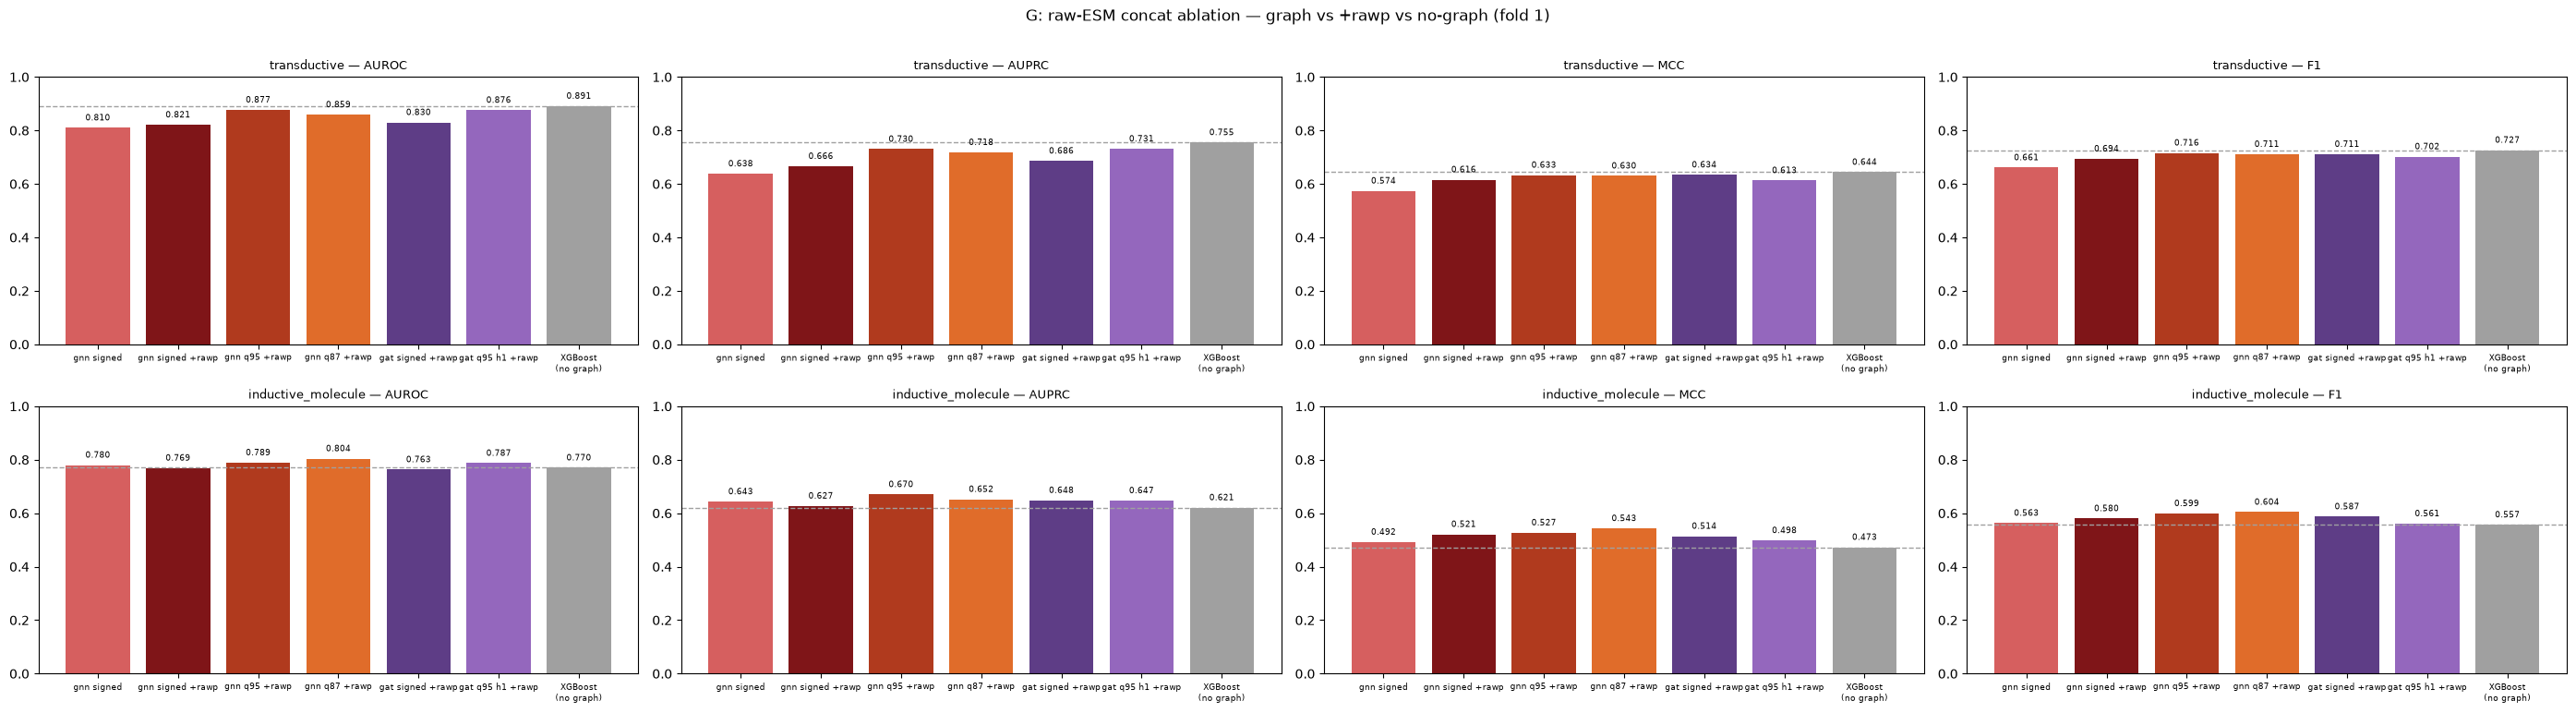

In [ ]:
# G: does the graph ADD signal, or just COMPRESS away raw ESM?
# Probe on [ChemBERTa || RAW ESM-1280 || z_prot] (rawp) vs graph-only vs baseline.
# Prediction: if graph only compresses -> rawp == baseline in both regimes.
#             if graph adds transferable signal -> rawp >= baseline, esp. inductive.
specs = [("gnn signed",          "#D65F5F", "gnn", "signed"),
         ("gnn signed +rawp",    "#7F1518", "gnn", "signed_rawp"),
         ("gnn q95 +rawp",       "#B03A1E", "gnn", "signed_q95_rawp"),
         ("gnn q87 +rawp",       "#E06C2A", "gnn", "signed_q87_rawp"),
         ("gat signed +rawp",    "#5E3D86", "gat", "signed_rawp"),
         ("gat q95 h1 +rawp",    "#9467BD", "gat", "signed_q95_hist1_rawp")]
plot_grid(specs, f"G: raw-ESM concat ablation — graph vs +rawp vs no-graph (fold {FOLD})",
          "graph_full_full_rawp", fs=6.5)

## Вывод

- **transductive-проигрыш графа бустингу — артефакт бутылочного горла**, а не «бустинг умнее»: вернёшь сырой ESM (`rawp`) — граф подрастает на 2/3 разрыва. Остаток — разбавление сильного сырого сигнала лишними `z_prot`-колонками.
- **inductive-выигрыш графа — реальный переносимый сигнал**: сырой ESM тут даже вредит (identity-память не обобщается на холодные молекулы).
- Т.е. «модель vs бустинг» — оба фактора, и `rawp` их чисто разделяет: transductive = недообученность/компрессия, baseline-edge = leak на identity.

## Part II ? Inductive molecule enrichment — can a COLD molecule's embedding be enriched?

In `inductive_molecule` the test molecule is held out entirely: it has **no edges**, so the
probe normally reads its **raw** features. The graph never gets to enrich it. This notebook
tests whether we can synthesise a graph neighbourhood for a cold molecule at inference time.

**Procedure** (frozen GNN, encoder + decoder, no retraining):
1. The decoder scores the cold molecule against every train protein → the top-k become
   **pseudo-edges**.
2. Message passing over `train graph + pseudo-edges` yields an enriched `z_mol`. Proteins
   evolve normally in that forward.
3. Re-predict edges from the new `z_mol`, repeat `T` times (fixed-point).
4. **Probe protein column always uses the frozen TRAIN `z_prot`** — never the test-forward
   proteins. Only the cold molecule's `z_mol` comes from this procedure.

## Validity ladder — how we check it actually works

Each bar is a full XGBoost probe (train on **all warm train edges**, test on cold edges;
protein column = frozen train `z_prot`). Warm train molecules always use their real graph `z_mol`
so train/test share one 64-d space; only cold molecules get the treatment.

| bar | cold-molecule representation | role |
|---|---|---|
| **raw** | raw compressed ChemBERTa | current inductive baseline |
| **noedge** | `z_mol` encoder output, no edges | encoding-vs-raw control |
| **imputed** | enriched via decoder top-k, `T` iters | **the proposal** |
| **random** | enriched via k random edges | negative control |
| **oracle** | enriched via TRUE test edges, leave-one-out | upper bound (headroom) |

Reading: **oracle − noedge** = how much headroom molecule-enrichment has at all; **imputed vs
oracle** = how much of it the decoder recovers; **imputed vs random** = whether the signal is real.

## Generate (reuses saved encoders; caches to CSV)

`G.main()` reconstructs each frozen GNN, runs the enrichment ladder for all seeds and writes
the cache. Oracle leave-one-out is the slow part (~1–2 min/seed); the whole run is a few
minutes. Re-running is instant once the CSV exists.

In [ ]:
# --- skinny shared: generate scores and select thresholds on cold validation ---
if not SPECTRUM_CSV.exists():
    print('generating shared enrichment ladder (frozen GNN; full-train XGBoost)...')
    G.main()
ENR = pd.read_csv(SPECTRUM_CSV)

VAL_THR_CSV = G.TABLES / 'inductive_enrichment_shared_val_threshold_by_seed.csv'
if not VAL_THR_CSV.exists():
    print('recomputing validation + test scores and selecting validation thresholds...')
    VAL_THR = G.run_val_thresholds('compressed_h64')
else:
    VAL_THR = pd.read_csv(VAL_THR_CSV)

print(f'{len(VAL_THR)} rows | seeds {sorted(VAL_THR.seed.unique())} | '
      f'bars {list(VAL_THR.bar.unique())}')
display(VAL_THR.groupby('bar')[
    ['AUROC','AUPRC','F1_at_0.5','F1_at_val_F1','MCC_at_0.5','MCC_at_val_MCC',
     'threshold_val_F1','threshold_val_MCC']].mean().reindex(G.BARS).round(3))


recomputing validation + test scores and selecting validation thresholds...
  nodes: 596 molecules, 1237 proteins | cold mols: 59 test / 29 val of 296 testable
  train: 2035 pos / 32596 neg (pos frac 0.059)
  val  : 94 pos / 206 neg (pos frac 0.313)
  test : 242 pos / 845 neg (pos frac 0.223)
seed 42 raw      tF1=0.31 tMCC=0.31 test F1=0.614 MCC=0.508
seed 42 noedge   tF1=0.01 tMCC=0.01 test F1=0.299 MCC=0.311
seed 42 imputed  tF1=0.23 tMCC=0.23 test F1=0.598 MCC=0.503
seed 42 random   tF1=0.78 tMCC=0.78 test F1=0.501 MCC=0.353
seed 42 oracle   tF1=0.89 tMCC=0.89 test F1=0.575 MCC=0.467
  nodes: 596 molecules, 1237 proteins | cold mols: 59 test / 29 val of 296 testable
  train: 1863 pos / 34640 neg (pos frac 0.051)
  val  : 70 pos / 370 neg (pos frac 0.159)
  test : 336 pos / 871 neg (pos frac 0.278)
seed 43 raw      tF1=0.44 tMCC=0.44 test F1=0.625 MCC=0.538
seed 43 noedge   tF1=0.01 tMCC=0.01 test F1=0.396 MCC=0.372
seed 43 imputed  tF1=0.97 tMCC=0.99 test F1=0.603 MCC=0.511
seed 43 

,AUROC,AUPRC,F1_at_0.5,F1_at_val_F1,MCC_at_0.5,MCC_at_val_MCC,threshold_val_F1,threshold_val_MCC
bar,,,,,,,,
raw,0.789,0.622,0.620,0.631,0.537,0.522,0.417,0.500
noedge,0.748,0.577,0.083,0.410,0.135,0.385,0.010,0.010
imputed,0.766,0.598,0.561,0.560,0.420,0.475,0.697,0.713
random,0.726,0.512,0.494,0.480,0.289,0.352,0.910,0.917
oracle,0.761,0.615,0.519,0.575,0.330,0.445,0.947,0.957


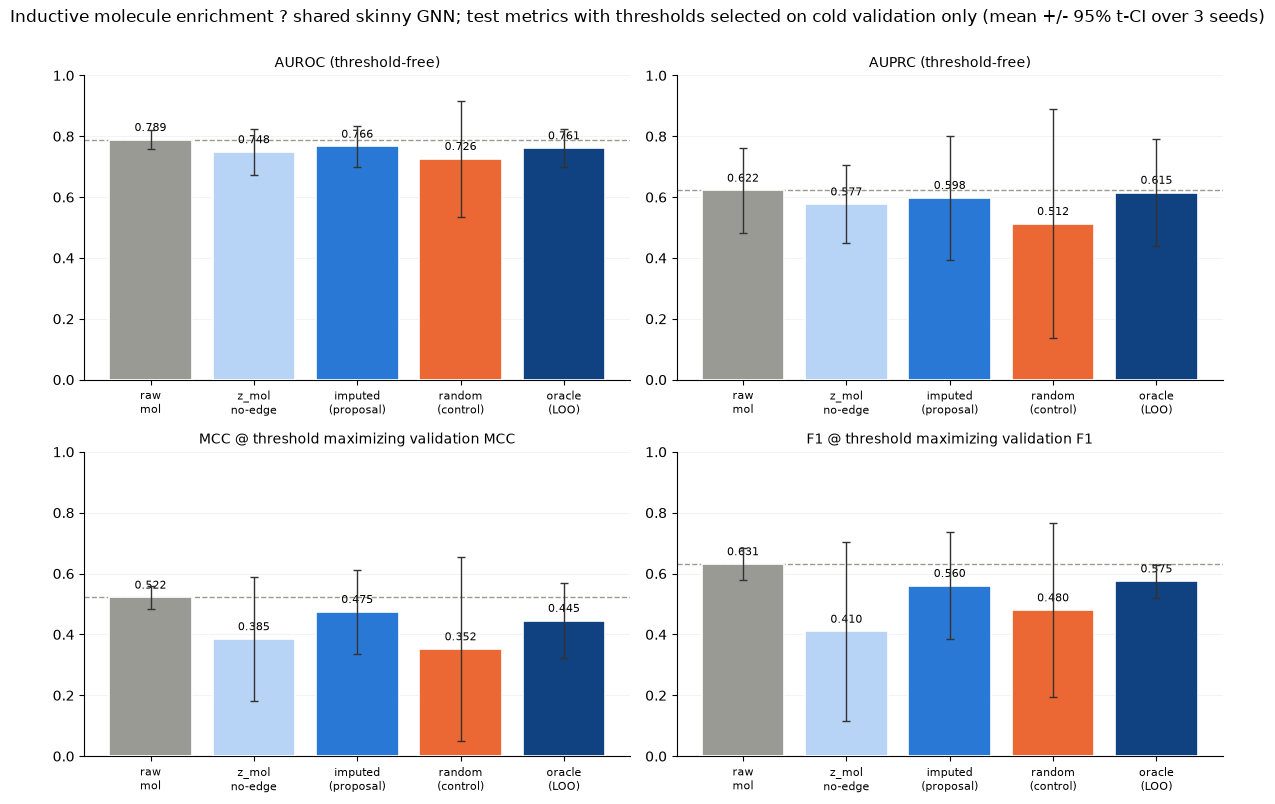

In [ ]:
# --- skinny validity ladder: test metrics, thresholds chosen ONLY on validation ---
BARS = ['raw', 'noedge', 'imputed', 'random', 'oracle']
LABEL = {'raw':'raw\nmol', 'noedge':'z_mol\nno-edge', 'imputed':'imputed\n(proposal)',
         'random':'random\n(control)', 'oracle':'oracle\n(LOO)'}
BAR_C = {'raw':'#9a9a95', 'noedge':'#b7d3f6', 'imputed':'#2a78d6',
         'random':'#eb6834', 'oracle':'#104281'}
PLOT_COLUMN = {'AUROC':'AUROC', 'AUPRC':'AUPRC',
               'MCC':'MCC_at_val_MCC', 'F1':'F1_at_val_F1'}
PLOT_TITLE = {'AUROC':'AUROC (threshold-free)', 'AUPRC':'AUPRC (threshold-free)',
              'MCC':'MCC @ threshold maximizing validation MCC',
              'F1':'F1 @ threshold maximizing validation F1'}

def valthr_agg(bar, metric):
    values = VAL_THR[VAL_THR.bar == bar][PLOT_COLUMN[metric]].to_numpy()
    stat = ci95(values)
    return stat['mean'], stat['ci_low'], stat['ci_high']

fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
for ax, metric in zip(axes.ravel(), METRICS):
    means, lows, highs = zip(*[valthr_agg(bar, metric) for bar in BARS])
    means = np.asarray(means, float)
    yerr = np.vstack([np.nan_to_num(means-np.asarray(lows,float)),
                      np.nan_to_num(np.asarray(highs,float)-means)])
    x = np.arange(len(BARS))
    ax.bar(x, means, color=[BAR_C[b] for b in BARS], edgecolor='white', linewidth=1.2,
           yerr=yerr, error_kw=dict(ecolor='#33322f', capsize=3, lw=1), zorder=3)
    ax.axhline(means[0], color=BAR_C['raw'], ls='--', lw=1, zorder=1)
    ax.set_title(PLOT_TITLE[metric], fontsize=10); ax.set_ylim(0,1)
    ax.grid(alpha=.15, axis='y'); ax.set_xticks(x)
    ax.set_xticklabels([LABEL[b] for b in BARS], fontsize=8)
    for side in ('top','right'): ax.spines[side].set_visible(False)
    for xi,value in zip(x,means):
        if np.isfinite(value):
            ax.text(xi,value+.02,f'{value:.3f}',ha='center',va='bottom',fontsize=8)
fig.suptitle('Inductive molecule enrichment ? shared skinny GNN; test metrics with '
             'thresholds selected on cold validation only '
             f'(mean +/- 95% t-CI over {VAL_THR.seed.nunique()} seeds)', fontsize=12.2, y=1.0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'inductive_molecule_enrichment_shared_val_threshold.png',
            dpi=150, bbox_inches='tight')
plt.show()


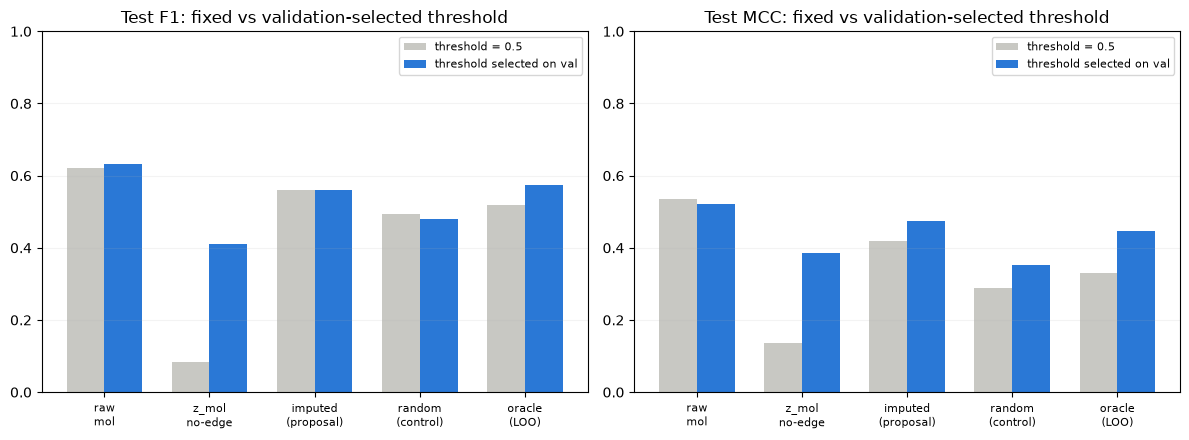

In [ ]:
# --- threshold diagnostic: fixed 0.5 versus validation-selected threshold ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), squeeze=False)
for ax, metric, fixed_col, tuned_col in [
    (axes[0,0], 'F1', 'F1_at_0.5', 'F1_at_val_F1'),
    (axes[0,1], 'MCC', 'MCC_at_0.5', 'MCC_at_val_MCC')]:
    x = np.arange(len(BARS)); width = .36
    fixed = VAL_THR.groupby('bar')[fixed_col].mean().reindex(BARS).to_numpy()
    tuned = VAL_THR.groupby('bar')[tuned_col].mean().reindex(BARS).to_numpy()
    ax.bar(x-width/2, fixed, width, color='#c8c8c3', label='threshold = 0.5')
    ax.bar(x+width/2, tuned, width, color='#2a78d6', label='threshold selected on val')
    ax.set_title(f'Test {metric}: fixed vs validation-selected threshold')
    ax.set_ylim(0,1); ax.grid(alpha=.15,axis='y'); ax.set_xticks(x)
    ax.set_xticklabels([LABEL[b] for b in BARS],fontsize=8)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'inductive_molecule_enrichment_threshold_diagnostic.png',
            dpi=150,bbox_inches='tight')
plt.show()


## How to read the result

- AUROC and AUPRC are threshold-free.
- F1 is evaluated on test at the threshold maximizing **validation F1**.
- MCC is evaluated on test at the threshold maximizing **validation MCC**.
- Test labels never select a threshold.
- The diagnostic chart shows how much of the previous no-edge collapse was calibration
  at threshold 0.5 versus a genuine loss of ranking signal.

The enrichment interpretation remains: imputed vs random tests whether predicted
neighbourhoods carry signal; raw is the deployment baseline. The current oracle is a
leave-one-out control, not a guaranteed upper bound because it may contain fewer than `k`
edges.


---

## Fat net — full embeddings, hidden 512

The shared ladder above ran on the **skinny compressed** GNN (mol pca16, prot pca32, hidden 64). Here we
repeat it on a **fat** net: **standardised** full embeddings (**ESM-1b 1280 + ChemBERTa 384**, per-dim mean-subtract + /sd — raw ESM is ~99% shared-mean, which would swamp the GNN) and **hidden 512** (2x the standard 256, 8x the compressed run). Same **shared** protocol and architecture (2-layer signed HeteroSAGE,
3-layer decoder), just much wider.

**Running this trains the model.** The generation cell trains 3 seeds from scratch if their
checkpoints are missing (~stable recipe: lr 1e-3, grad-clip 1.0, ReduceLROnPlateau, 600 epochs),
then runs the same 5-bar validity ladder on the fat encoders. Expect a long first run (full 1280-d
inputs at hidden 512 on CPU); re-runs are instant once checkpoints + the CSV exist.

In [ ]:
# --- FAT net: train (if needed) then run the enrichment ladder ---
FAT_OUT = G.CONFIGS['full_h512']['out']
if FAT_OUT.exists():
    ENR_FAT = pd.read_csv(FAT_OUT)
    print('loaded cached fat ladder:', FAT_OUT.relative_to(ROOT))
else:
    print('training the fat net (3 seeds) then running the ladder — this is the long part...')
    ENR_FAT = G.run_ladder('full_h512')      # trains missing checkpoints, then probes
print(f'{len(ENR_FAT)} rows | seeds {sorted(ENR_FAT.seed.unique())}')
ENR_FAT.groupby('bar')[METRICS].mean().reindex(G.BARS).round(3)

training the fat net (3 seeds) then running the ladder — this is the long part...
[fat] seed 42: training SHARED (hidden 512, full embeddings, 600 epochs)...


In [ ]:
# --- fat-net validity-ladder chart (mean +/- 95% t-CI over seeds) ---
def plot_ladder(df, title_suffix, savename):
    BARS = ['raw', 'noedge', 'imputed', 'random', 'oracle']
    LABEL = {'raw': 'raw\nmol', 'noedge': 'z_mol\nno-edge', 'imputed': 'imputed\n(proposal)',
             'random': 'random\n(control)', 'oracle': 'oracle\n(LOO)'}
    BAR_C = {'raw': '#9a9a95', 'noedge': '#b7d3f6', 'imputed': '#2a78d6',
             'random': '#eb6834', 'oracle': '#104281'}
    def agg(bar, metric):
        s = ci95(df[df.bar == bar][metric].to_numpy()); return s['mean'], s['ci_low'], s['ci_high']
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
    for ax, metric in zip(axes.ravel(), METRICS):
        means, los, his = zip(*[agg(b, metric) for b in BARS])
        means = np.array(means, float)
        yerr = np.vstack([np.nan_to_num(means - np.array(los, float)),
                          np.nan_to_num(np.array(his, float) - means)])
        x = np.arange(len(BARS))
        ax.bar(x, means, color=[BAR_C[b] for b in BARS], edgecolor='white', linewidth=1.2,
               yerr=yerr, error_kw=dict(ecolor='#33322f', capsize=3, lw=1), zorder=3)
        ax.axhline(means[0], color=BAR_C['raw'], ls='--', lw=1, zorder=1)
        ax.set_title(metric, fontsize=11); ax.set_ylim(0, 1); ax.grid(alpha=.15, axis='y')
        ax.set_xticks(x); ax.set_xticklabels([LABEL[b] for b in BARS], fontsize=8)
        for s in ('top', 'right'): ax.spines[s].set_visible(False)
        for xi, v in zip(x, means):
            if np.isfinite(v):
                ax.text(xi, v + .02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    fig.suptitle(f'Inductive molecule enrichment {title_suffix} '
                 f'(mean +/- 95% t-CI over {df.seed.nunique()} seeds; dashed = raw baseline)',
                 fontsize=12.5, y=1.0)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / savename, dpi=150, bbox_inches='tight')
    plt.show()

plot_ladder(ENR_FAT, '— FAT net (full emb, hidden 512)', 'inductive_molecule_enrichment_fat_ladder.png')

**Fat vs skinny read:** compare this ladder to the compressed one. The question the width test
answers is whether the graph's molecule bottleneck was a *capacity* problem (then the fat z_mol
should close the gap to raw and lift oracle above noedge) or a *signal* problem (then more width
changes little and raw still wins). Watch especially **oracle − noedge** (headroom) and
**raw − imputed** (does the fat graph embedding finally match raw features).

## Integrated interpretation

The two analyses answer complementary questions:

- The **raw-ESM ablation** concerns the protein side: some transductive deficit came from forcing
  a rich protein embedding through a graph bottleneck.
- The **enrichment ladder** concerns the molecule side: a genuinely cold molecule has no observed
  neighbours, so graph enrichment must be created at inference time rather than assumed.
- `noedge` isolates the root/projection transformation; `random` tests whether merely adding edges
  helps; `oracle ? noedge` measures available neighbourhood headroom; `imputed ? random` measures
  whether the decoder finds meaningful neighbours.
- The **fat-vs-skinny** comparison decides whether failures are mainly capacity-limited. If width
  does not close `raw ? imputed`, the limiting factor is neighbour inference or missing signal,
  not embedding dimensionality alone.

Accordingly, transductive success cannot be carried over automatically to inductive deployment:
protein-side context may transfer, while molecule-side context is absent unless it is explicitly
reconstructed.
